# SEELAI: Train YOLOv8n & Export to TFLite

Ultralytics YOLOv8 Nano is the perfect, lightweight object detection model for mobile applications. In this notebook, we will prepare the environment, download our augmented Roboflow dataset, train the model, visualize the precision/recall graphs, and export the final weights to a highly optimized TensorFlow Lite (.tflite) format for mobile deployment.

Pro Tip: Use GPU Acceleration
Navigate to Edit -> Notebook settings -> Hardware accelerator, set it to T4 GPU, and then click Save. This will significantly speed up your training time.

**1. Hardware Check**

Let's make sure we have access to the GPU before starting.

In [1]:
!nvidia-smi

Fri May 22 07:56:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**2. Setup Workspace & Install YOLOv8**

Set up the current working directory and install the necessary libraries, including ultralytics for YOLO and roboflow for dataset management.

In [2]:
import os
HOME = os.getcwd()
print("Working Directory:", HOME)

!pip install --upgrade ultralytics

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6841.9/8062.4 GB disk)


**3. Download Custom Dataset from Roboflow**

We will download the augmented dataset directly from Roboflow Universe.


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="wtru0Ykkig3JX15h70VZ")
project = rf.workspace("seelais-workspace").project("seelai-objects-s7rir")
version = project.version(4)
dataset = version.download("yolov8")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.1 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery


Extracting Dataset Version Zip to Seelai-Objects-4 in yolov8:: 100%|██████████| 30849/30849 [00:02<00:00, 11984.77it/s]


**4. Custom Training (YOLOv8 Nano)**

Now we train the model! We are using yolov8n.pt because it is the fastest for mobile. The plots=True argument ensures that all your precision, recall, and loss graphs are generated for your thesis documentation.

In [4]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=/kaggle/working/Seelai-Objects-4/data.yaml epochs=120 imgsz=320 plots=True batch=32 patience=25 name=seelai_object_detection

/kaggle/working
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Seelai-Objects-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seelai_object_detection, nbs=64, nms=False, opset=None, optimize=False, 

**5. Evaluate the Model (Thesis Graphs)**

Once training is finished, let's display the evaluation graphs. These are the exact charts you will need to put in your thesis manuscript to prove the model's accuracy.

# Confusion Matrix:

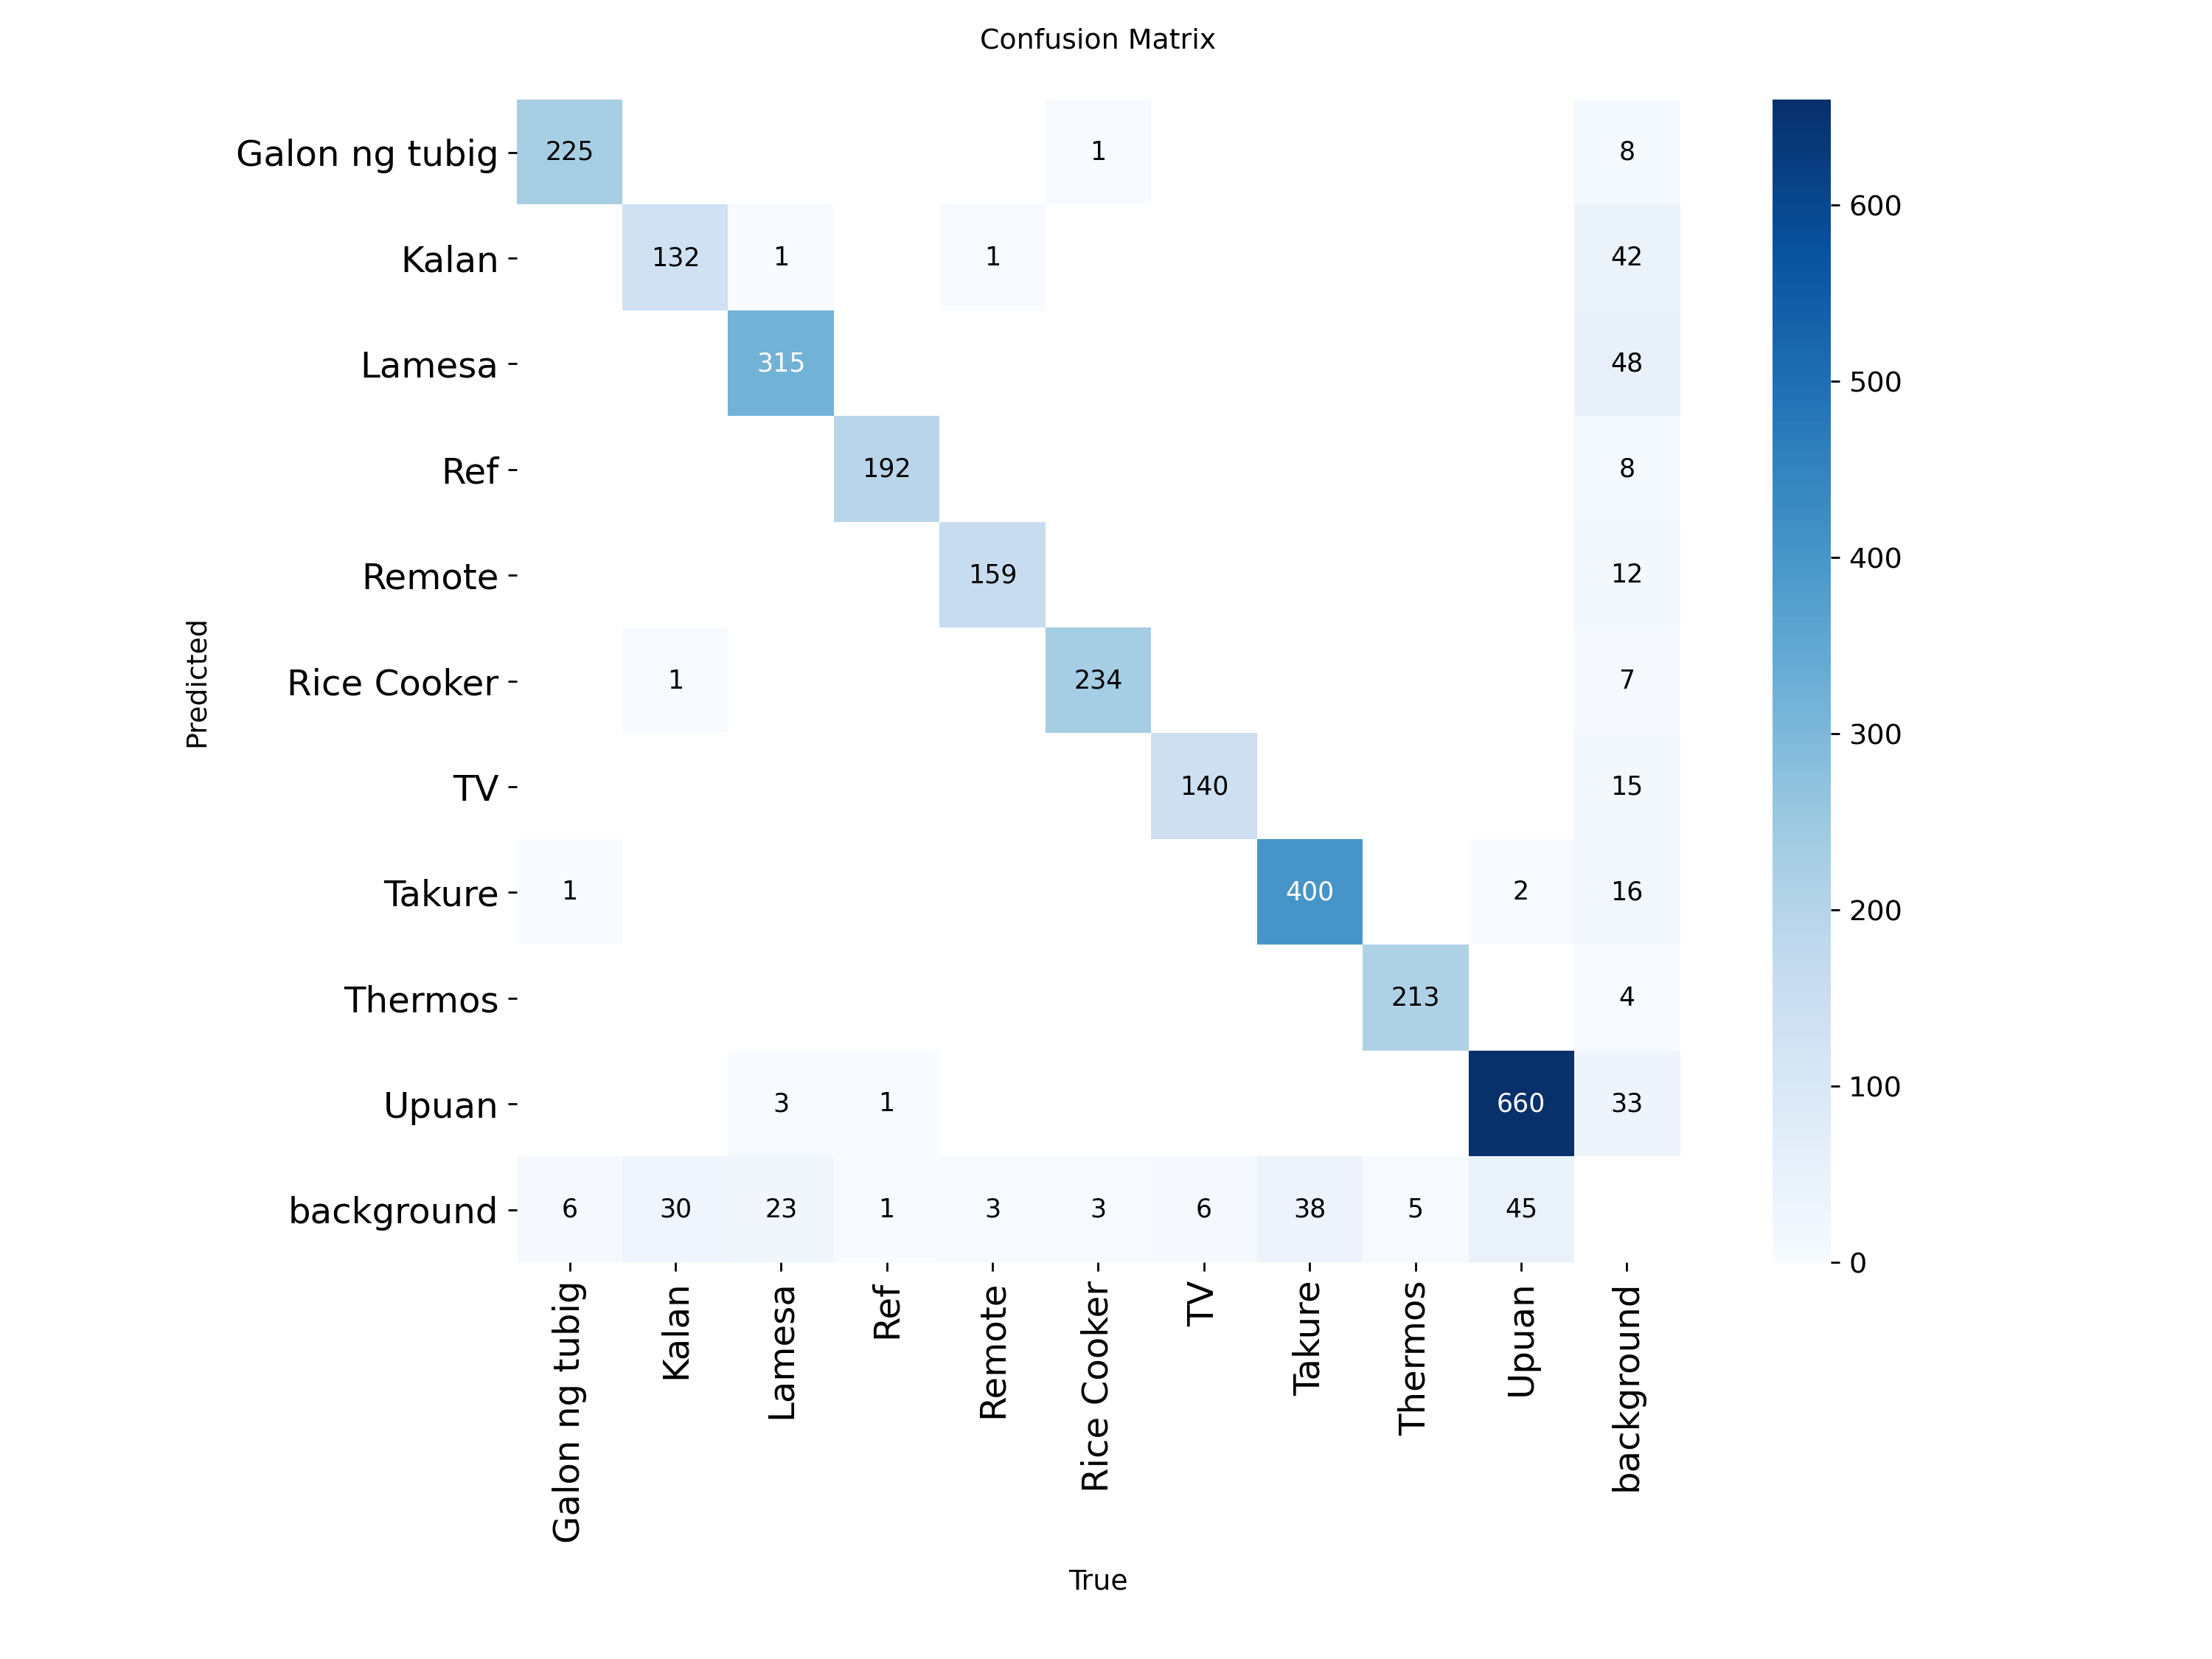

In [5]:
from IPython.display import Image, display

image_path = f'{HOME}/runs/detect/seelai_object_detection/confusion_matrix.png'

display(Image(filename=image_path, width=800))

# Training Results (Loss, mAP, Precision, Recall):

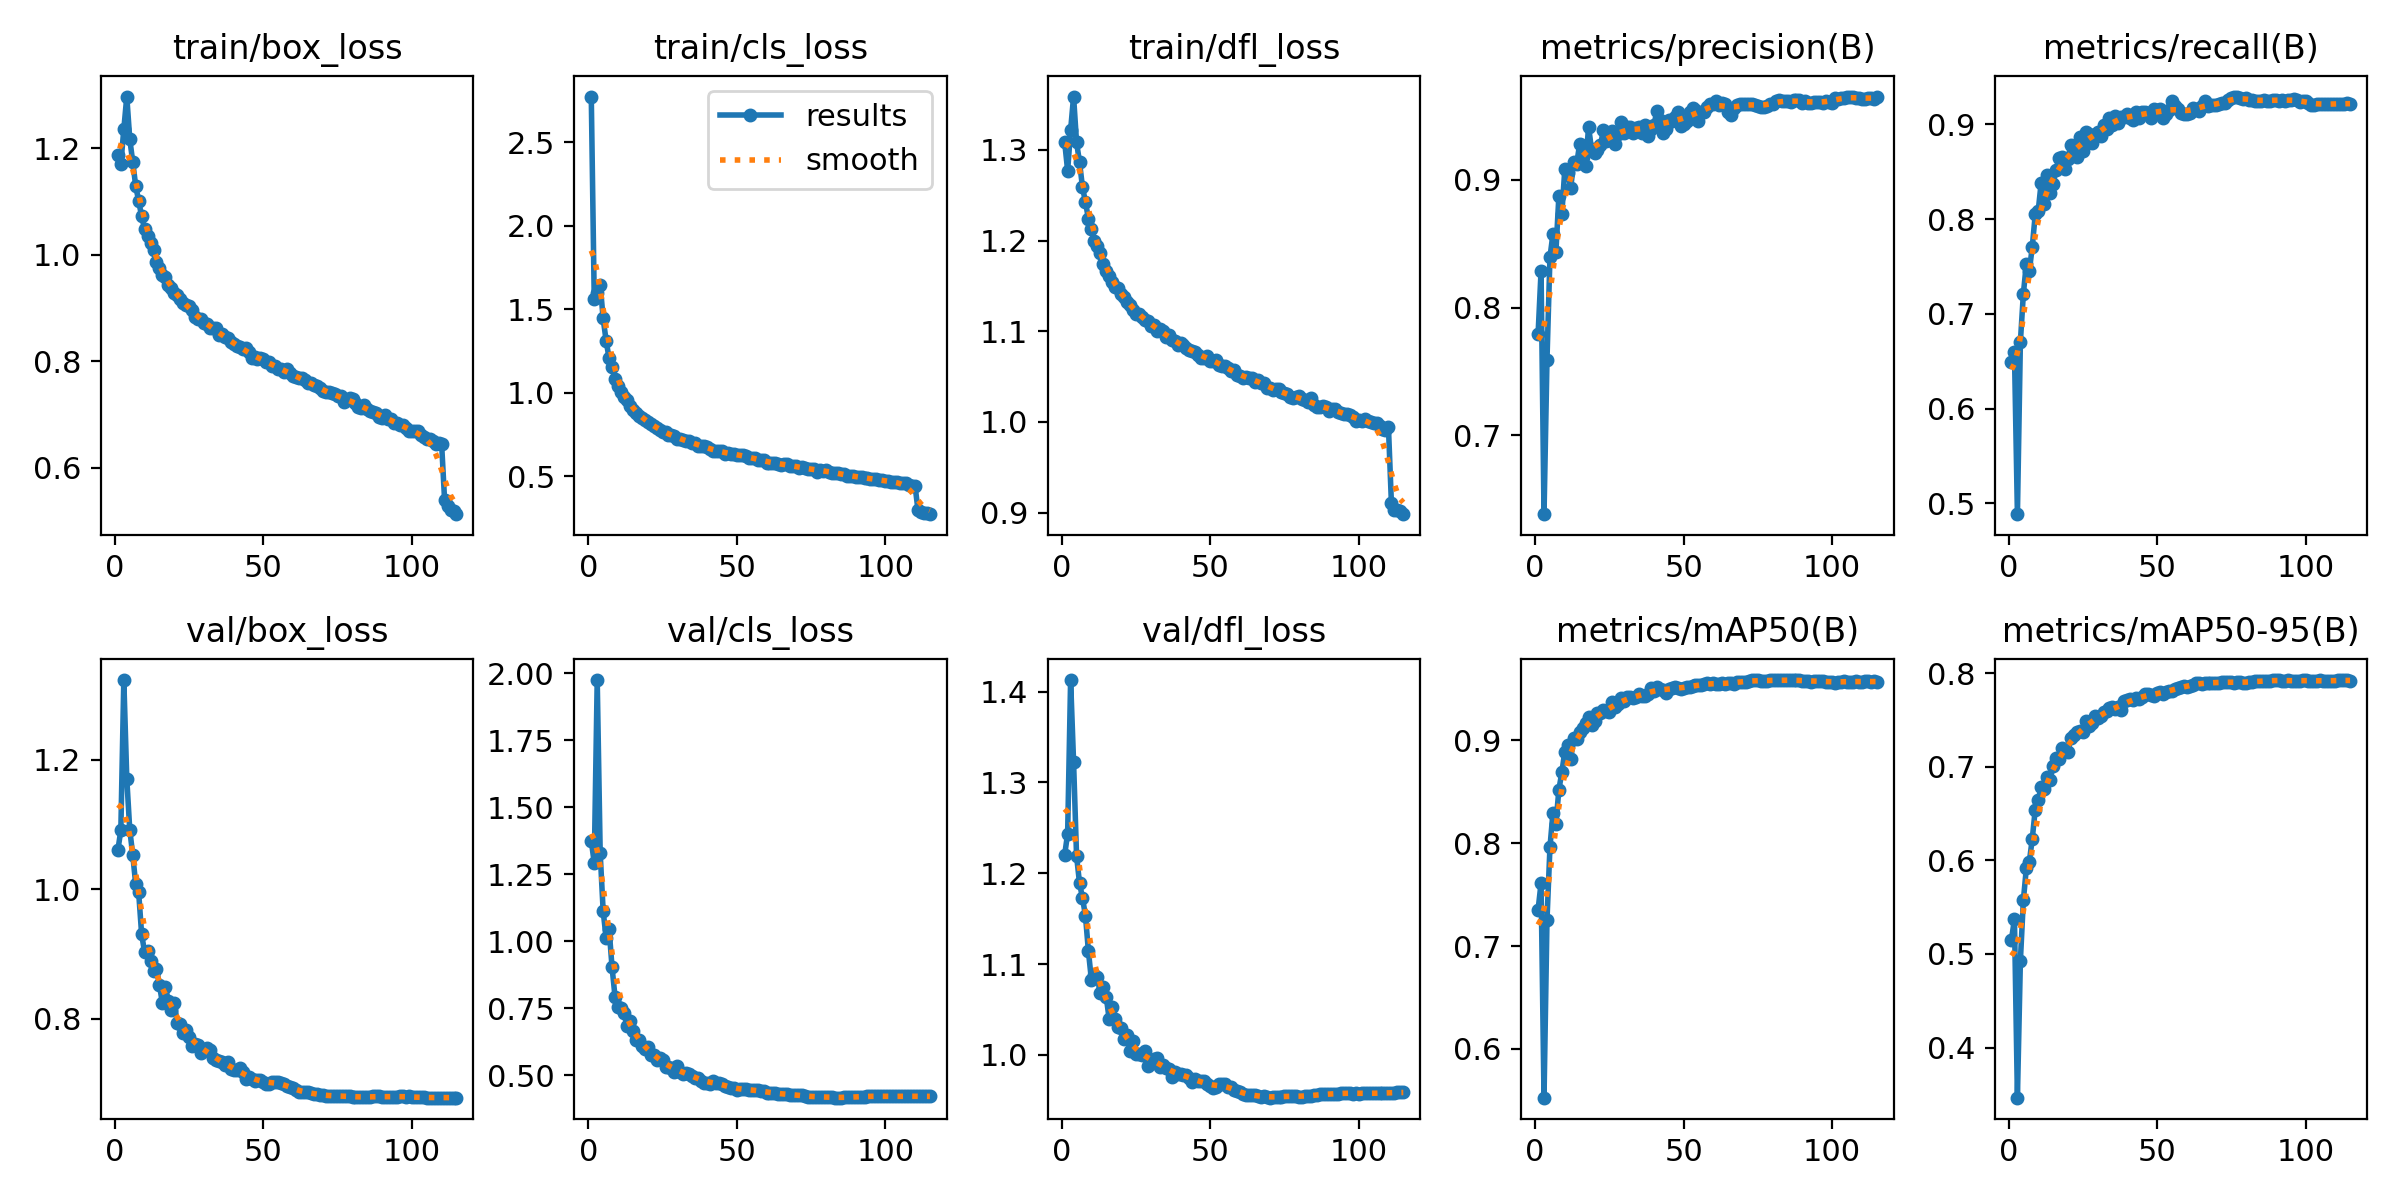

In [7]:
from IPython.display import Image, display

image_path = f'{HOME}/runs/detect/seelai_object_detection/results.png'

display(Image(filename=image_path, width=800))

# Validation Predictions (Qualitative Check):

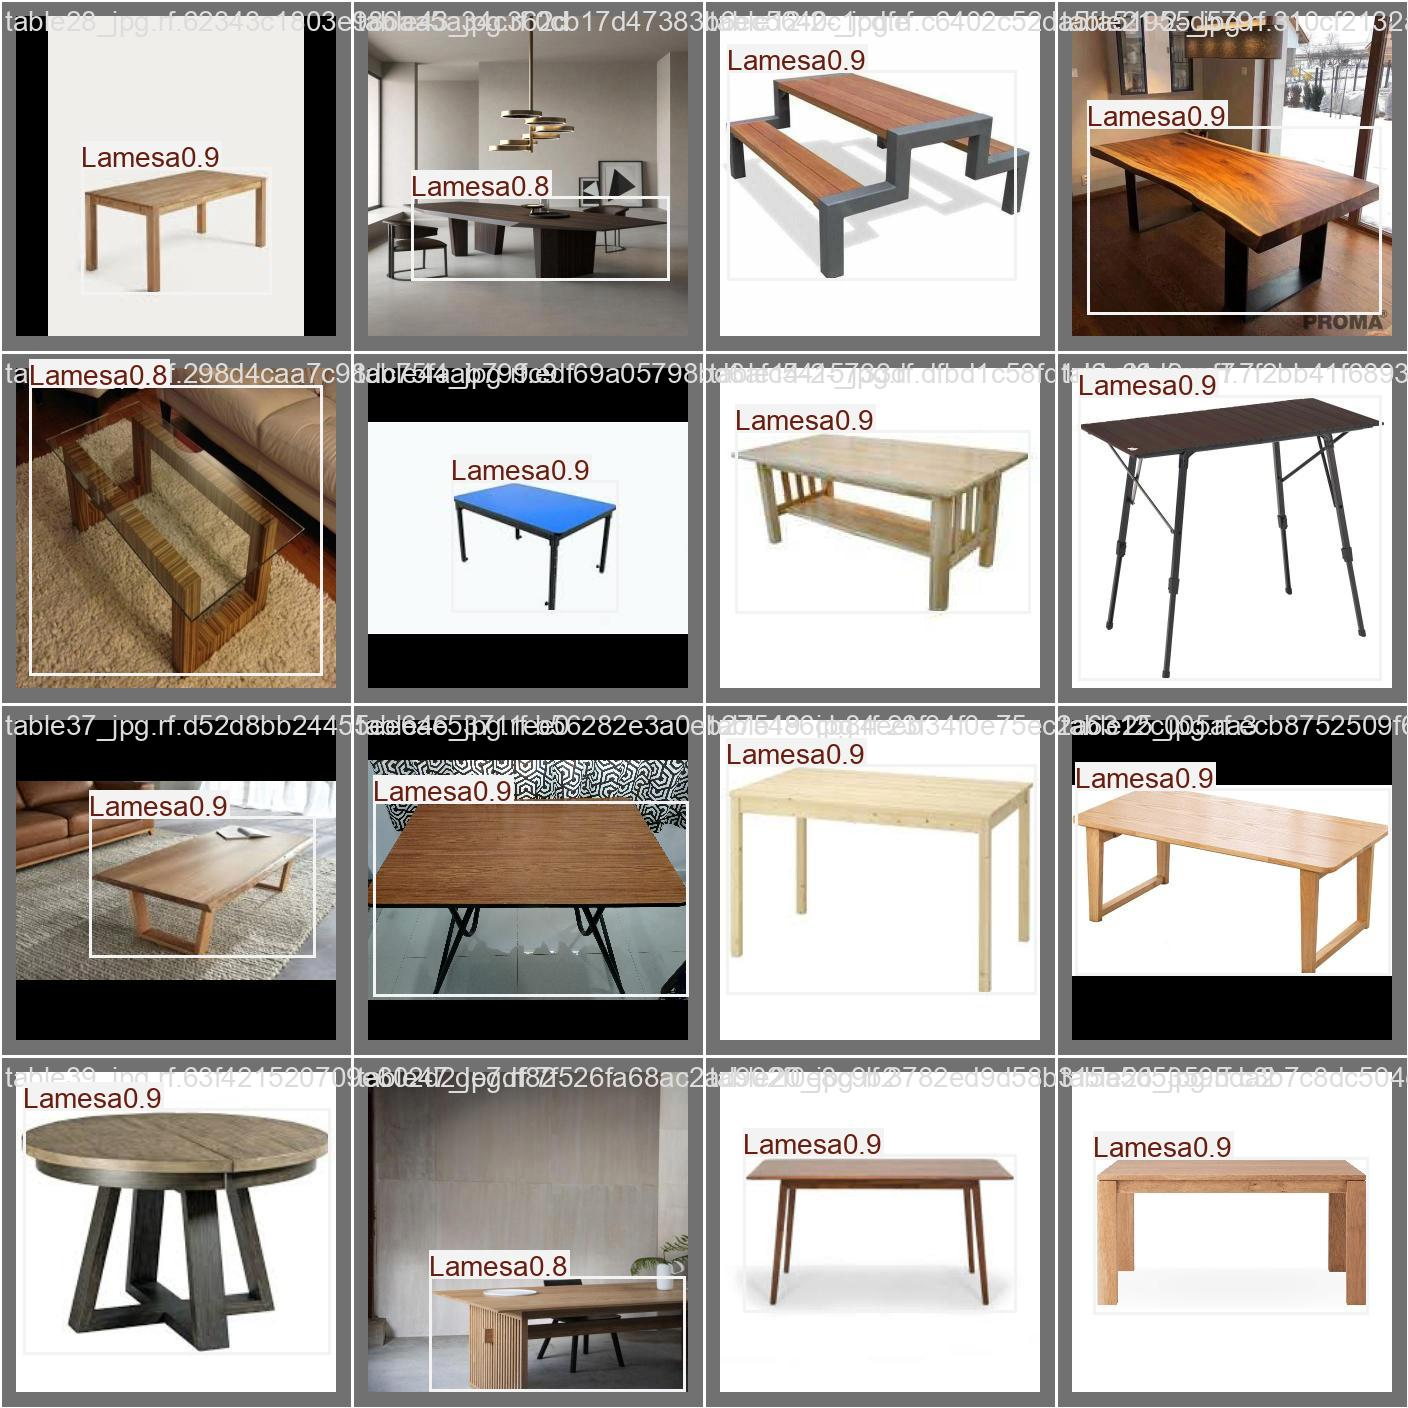

In [8]:
from IPython.display import Image, display

image_path = f'{HOME}/runs/detect/seelai_object_detection/val_batch0_pred.jpg'

display(Image(filename=image_path, width=800))

**5.1 Print Total Overall Metrics**



In [9]:
%cd {HOME}
from ultralytics import YOLO

model = YOLO(f"{HOME}/runs/detect/seelai_object_detection/weights/best.pt")

metrics = model.val(data=f"{dataset.location}/data.yaml")

print("\n" + "="*40)
print("SEELAI MODEL: TOTAL OVERALL METRICS")
print("="*40)
print(f"Total Precision:   {metrics.box.mp * 100:.2f}%")
print(f"Total Recall:      {metrics.box.mr * 100:.2f}%")
print(f"Total mAP@50:      {metrics.box.map50 * 100:.2f}%")
print(f"Total mAP@50-95:   {metrics.box.map * 100:.2f}%")
print("="*40 + "\n")

/kaggle/working
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 384.4±200.0 MB/s, size: 9.7 KB)
val: Scanning /kaggle/working/Seelai-Objects-4/valid/labels.cache... 1814 images, 53 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1814/1814 70.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 25, len(boxes) = 2841. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 114/114 13.1it/s 8.7s0.1s
                   all       1814       2841      0.961      0.926      0.958      0.792
        Galon ng tubig        203        232      0.977      0.961      0.989      0.852
   

**6. Export to TFLite with INT8 Quantization (Mobile Optimization)**

This is the most critical step for SEELAI. Standard PyTorch models (.pt) are too heavy for smooth Flutter integration. We will export the "best" training weights to TensorFlow Lite format.

By setting int8=True, we apply Post-Training Quantization. This shrinks the model size by roughly 4x and speeds up mobile inference, with only a tiny, negligible drop in accuracy.

In [12]:
%cd {HOME}

!yolo export model={HOME}/runs/detect/seelai_object_detection/weights/best.pt \
format=tflite \
half=True \
imgsz=320 \
data=/kaggle/working/Seelai-Objects-4/data.yaml

/kaggle/working
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/detect/seelai_object_detection/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 14, 2100) (5.9 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.3s, saved as '/kaggle/working/runs/detect/seelai_object_detection/weights/best.onnx' (11.6 MB)
E0000 00:00:1779444836.003467     363 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779444836.009685     363 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779444836.026440     363 computation_placer.cc:177] computation p

**7. Download Your Mobile Model!**

After the export finishes, your quantized mobile model is ready. You can download it directly to your machine to place inside your Flutter app's assets folder.

In [11]:
from IPython.display import FileLink, display

tflite_path = f"{HOME}/runs/detect/seelai_object_detection/weights/best_saved_model/best_float16.tflite"

display(FileLink(tflite_path))

/kaggle/working/runs/detect/seelai_object_detection-2/weights/best_saved_model/best_int8.tflite